In [1]:
# ============================================================
# 🧠 EMNIST CNN for Uppercase + Lowercase Handwritten Letters
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow_datasets as tfds
from PIL import Image
import os

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# ----------------------------
# 1. Load EMNIST ByClass Dataset
# ----------------------------
dataset, info = tfds.load('emnist/byclass', as_supervised=True, with_info=True)
train_ds, test_ds = dataset['train'], dataset['test']

In [ ]:
# ----------------------------
# 2. Filter & Preprocess Data
# ----------------------------

# Keep only letters (A–Z, a–z)
def is_letter(image, label):
    return label >= 10  # letters are labeled 10–61

# Normalize, rotate, and remap labels
def normalize_and_remap(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    
    # EMNIST images need rotation + vertical flip
    image = tf.image.transpose(image)     # rotate
    image = tf.image.flip_left_right(image)  # flip horizontally to correct orientation
    
    # Remap 10–61 → 0–51 (A–Z → 0–25, a–z → 26–51)
    return image, label - 10


train_ds = train_ds.filter(is_letter).map(normalize_and_remap, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.filter(is_letter).map(normalize_and_remap, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(128).cache().prefetch(tf.data.AUTOTUNE)

In [4]:
# ----------------------------
# 3. Build CNN Model
# ----------------------------
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(52, activation='softmax')  # 52 = A–Z + a–z
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\Windows\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 52)             │        13,364 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 908,084 (3.46 MB)

 Trainable params: 907,700 (3.46 MB)

 Non-trainable params: 384 (1.50 KB)

In [5]:
# ----------------------------
# 4. Train Model
# ----------------------------
history = model.fit(train_ds, epochs=15, validation_data=test_ds)

Epoch 1/15
   2758/Unknown 237s 85ms/step - accuracy: 0.7353 - loss: 0.9141

c:\Users\Windows\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2758/2758 ━━━━━━━━━━━━━━━━━━━━ 257s 92ms/step - accuracy: 0.7906 - loss: 0.6580 - val_accuracy: 0.8421 - val_loss: 0.4480
Epoch 2/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 367s 133ms/step - accuracy: 0.8335 - loss: 0.4774 - val_accuracy: 0.8516 - val_loss: 0.4082
Epoch 3/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 363s 131ms/step - accuracy: 0.8450 - loss: 0.4344 - val_accuracy: 0.8536 - val_loss: 0.3917
Epoch 4/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 499s 181ms/step - accuracy: 0.8513 - loss: 0.4101 - val_accuracy: 0.8543 - val_loss: 0.3889
Epoch 5/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 530s 192ms/step - accuracy: 0.8556 - loss: 0.3934 - val_accuracy: 0.8575 - val_loss: 0.3877
Epoch 6/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 466s 169ms/step - accuracy: 0.8591 - loss: 0.3789 - val_accuracy: 0.8611 - val_loss: 0.3773
Epoch 7/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 497s 180ms/step - accuracy: 0.8628 - loss: 0.3649 - val_accuracy: 0.8596 - val_loss: 0.3754
Epoch 8/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 261s 95ms/step - accuracy: 0.865

In [6]:
# ----------------------------
# 5. Evaluate Model
# ----------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.3f}")

457/457 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8620 - loss: 0.4196
✅ Test Accuracy: 0.862


In [7]:
# ----------------------------
# 6. Save Model
# ----------------------------
# --- CHANGE --- (Optional, but good practice)
model.save("emnist_byclass_cnn_v2.h5")
print("Model saved as 'emnist_byclass_cnn_v2.h5'")

Model saved as 'emnist_byclass_cnn_v2.h5'


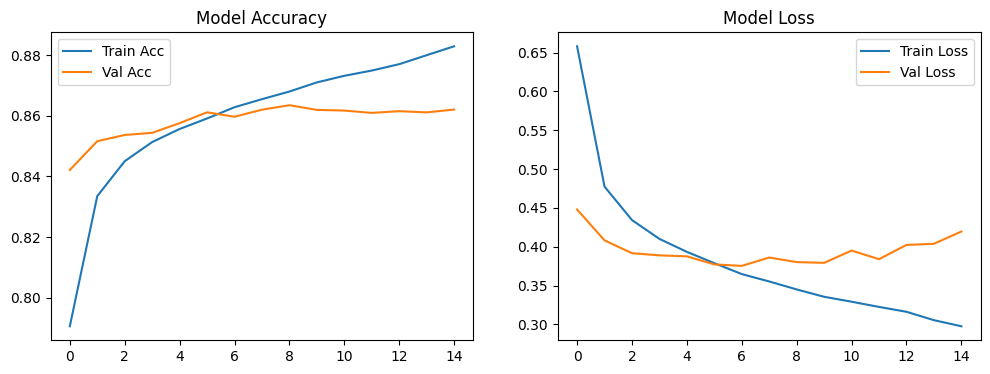

In [8]:
# ----------------------------
# 7. Accuracy & Loss Plots
# ----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━

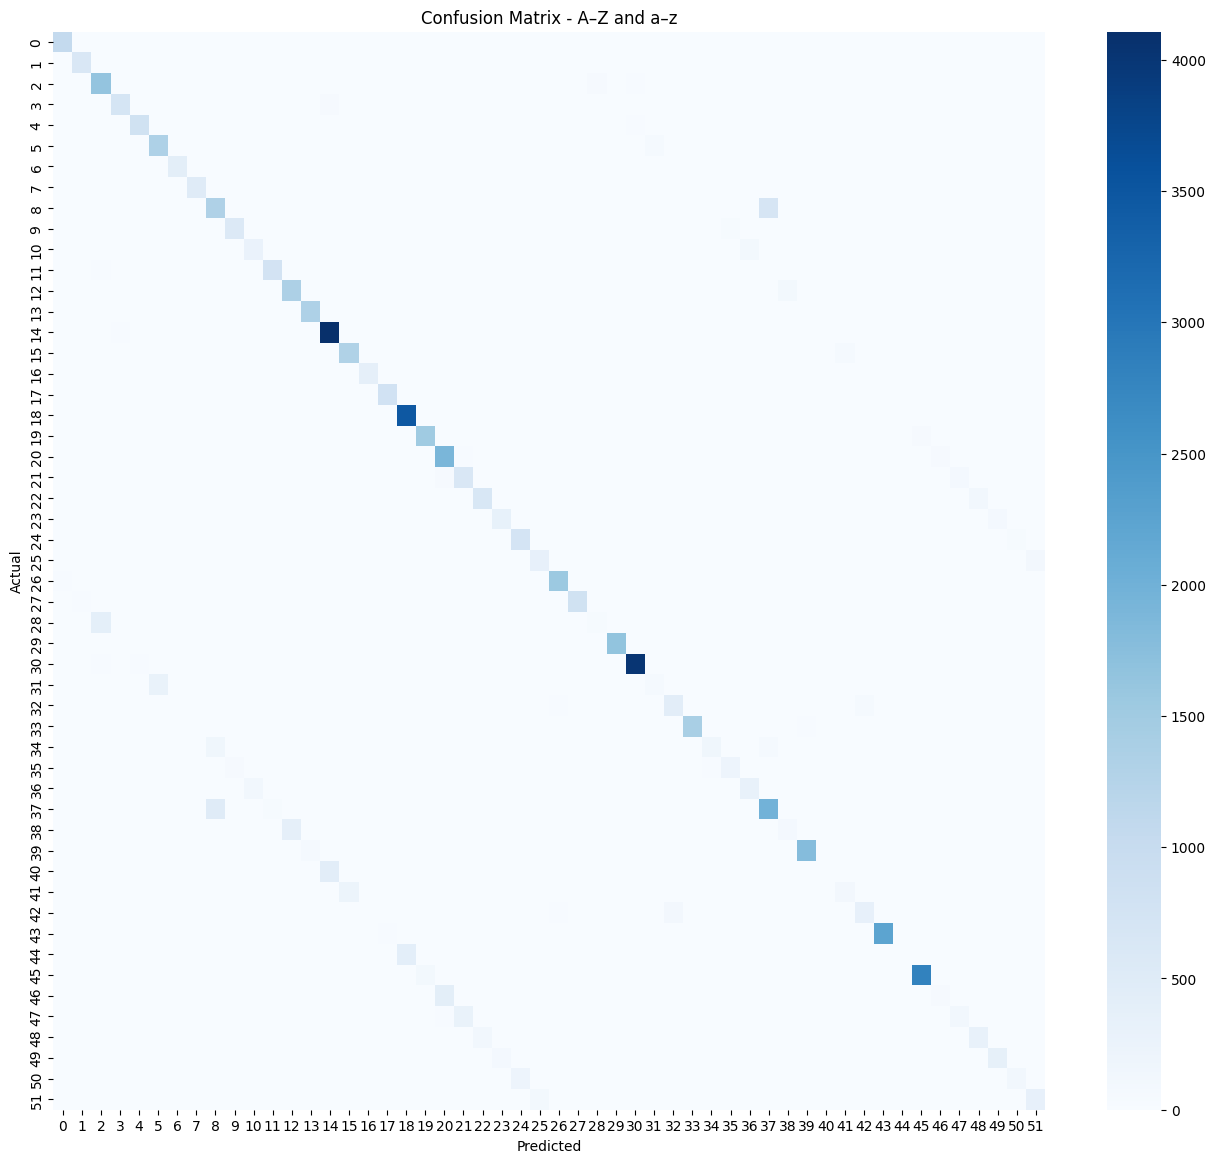

              precision    recall  f1-score   support

           A       0.95      0.98      0.96      1062
           B       0.96      0.97      0.96       648
           C       0.78      0.94      0.85      1739
           D       0.94      0.91      0.93       779
           E       0.97      0.95      0.96       851
           F       0.80      0.93      0.86      1440
           G       0.97      0.97      0.97       447
           H       0.95      0.97      0.96       521
           I       0.66      0.65      0.65      2048
           J       0.88      0.90      0.89       626
           K       0.66      0.71      0.69       382
           L       0.92      0.94      0.93       810
           M       0.77      0.92      0.84      1485
           N       0.93      0.99      0.96      1351
           O       0.88      0.99      0.93      4156
           P       0.84      0.94      0.88      1397
           Q       0.94      0.92      0.93       413
           R       0.94    

In [9]:
# ----------------------------
# 8. Confusion Matrix
# ----------------------------
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix - A–Z and a–z")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

target_names_upper = [chr(i) for i in range(65, 91)]  # A–Z
target_names_lower = [chr(i) for i in range(97, 123)] # a–z
print(classification_report(y_true, y_pred, target_names=target_names_upper + target_names_lower))

Collected all 52 letter examples.


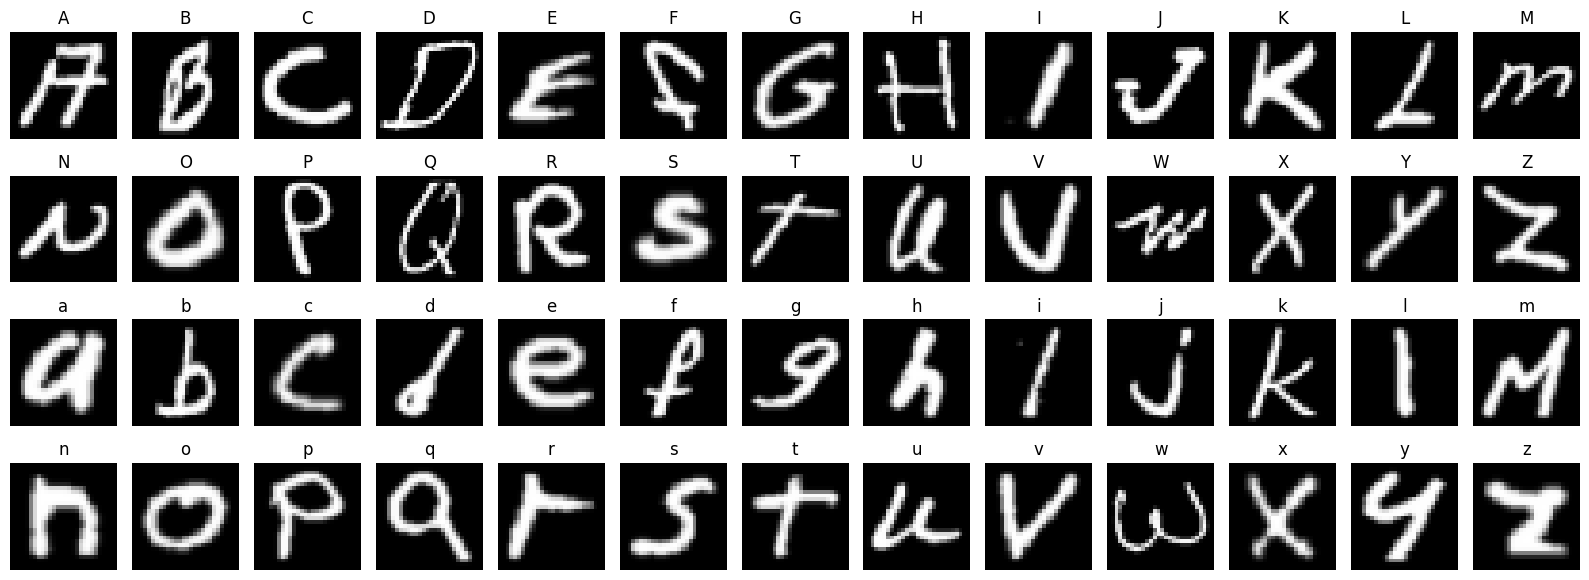

In [10]:
# ----------------------------
# 8. Display all letters
# ----------------------------
# --- CHANGE ---
# Collect one example per letter (0-51)
letter_images = [None] * 52

# We iterate over the preprocessed, filtered, and remapped dataset
for image, label in test_ds.unbatch():
    idx = int(label.numpy()) # idx is now 0-51
    if idx >= 0 and idx < 52:
        if letter_images[idx] is None:
            letter_images[idx] = image.numpy().squeeze()
    
    # Optimization: stop when we have all 52
    if all(img is not None for img in letter_images):
        print("Collected all 52 letter examples.")
        break

plt.figure(figsize=(16, 6))
rows = 4
cols = 13
for i, img in enumerate(letter_images):
    plt.subplot(rows, cols, i + 1)
    
    # Get correct title based on 0-51 index
    if i < 26:
        title = chr(i + 65)  # 0-25 -> A-Z
    else:
        title = chr((i - 26) + 97) # 26-51 -> a-z
        
    # Check if image was found
    if img is not None:
        plt.imshow(img, cmap='gray')
        plt.title(title)
    else:
        plt.title(f"{title} (N/A)")
        
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


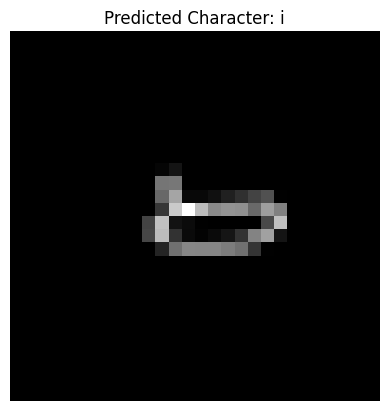

✅ Predicted Character: i


In [21]:
# ============================================================
# 🧩 PREDICTION FROM CUSTOM HANDWRITTEN IMAGE
# ============================================================

model_path = r"C:\Users\Windows\Desktop\SMART LEARNING\smart-learning-backend\python-services\emnist_byclass_cnn_v2.h5"
model = tf.keras.models.load_model(model_path)

# Define 52 labels
target_names_upper = [chr(i) for i in range(65, 91)]  # A–Z
target_names_lower = [chr(i) for i in range(97, 123)] # a–z
model_labels = target_names_upper + target_names_lower

# Preprocessing for external handwritten input
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((28, 28))
    img = np.array(img)

    # EMNIST orientation fix (same as training)
    img = np.rot90(img, k=1)
    img = np.fliplr(img)

    # Invert color to match EMNIST white-on-black
    img = 255 - img
    img = img / 255.0

    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    return img

# Test Image Path (replace with your image)
image_path = r"C:\Users\Windows\Desktop\SMART LEARNING\smart-learning-backend\python-services\letter_a.png"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"❌ Input image not found at:\n{image_path}")

img_input = preprocess_image(image_path)
pred = model.predict(img_input)
pred_index = np.argmax(pred)
predicted_char = model_labels[pred_index]

plt.imshow(np.squeeze(img_input), cmap='gray')
plt.title(f"Predicted Character: {predicted_char}")
plt.axis('off')
plt.show()

print(f"✅ Predicted Character: {predicted_char}")